In [1]:
#yum install sqlite-devel
%pip install matplotlib
%pip install panda

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import os

In [3]:
p = os.getcwd()
PROJECT_PATH = os.path.join(p.split('change_aware_utg')[0],'change_aware_utg')
print(PROJECT_PATH)
BENCHMARK_PATH = os.path.join(PROJECT_PATH, "UTG_python_external_benchmark_light")
print(BENCHMARK_PATH)

/mnt/efs/people/rabaisha/GitLab/change_aware_utg
/mnt/efs/people/rabaisha/GitLab/change_aware_utg/UTG_python_external_benchmark_light


In [9]:
fm_stat="bedrock_experiment/focal_method_statistics/Results/properties_of_fm.csv"
#Similar to the previous result, I also keep all cyclomatic complexity and line numbers in the project specific csv.
#https://gitlab.aws.dev/rabaisha/change_aware_utg/-/tree/master/bedrock_experiment/focal_method_statistics/Results?ref_type=heads
test_stat="test_analysis/Results/1072_tests_with_Focal_Methods_with_code_coverage.csv"
fm_test_stat="bedrock_experiment/Results/Combined_result_of_fm_and_tests.csv" 
proj_stat="data/project_repo.csv"
execution="data/execution.csv"

In [10]:
def if_file_exists(file_path):
    if os.path.exists(file_path):
        print(f"The file {file_path} exists.")
        return True
    else:
        print(f"The file {file_path} does not exist.")
        return False

In [54]:
fm_stat_path = os.path.join(PROJECT_PATH,fm_stat) 
assert(if_file_exists(fm_stat_path)==True)

test_stat_path = os.path.join(PROJECT_PATH,test_stat) 
assert(if_file_exists(test_stat_path)==True)

fm_test_stat_path = os.path.join(PROJECT_PATH,fm_test_stat) 
assert(if_file_exists(fm_test_stat_path)==True)# Read a CSV file from a URL

proj_path=os.path.join(BENCHMARK_PATH,proj_stat)
assert(if_file_exists(proj_path)==True)

exec_path=os.path.join(BENCHMARK_PATH,execution)
assert(if_file_exists(exec_path)==True)

df_fm   = pd.read_csv(fm_stat_path)
df_test = pd.read_csv(test_stat_path)
df_both = pd.read_csv(fm_test_stat_path)
df_proj = pd.read_csv(proj_path)
df_exec = pd.read_csv(exec_path)

The file /mnt/efs/people/rabaisha/GitLab/change_aware_utg/bedrock_experiment/focal_method_statistics/Results/properties_of_fm.csv exists.
The file /mnt/efs/people/rabaisha/GitLab/change_aware_utg/test_analysis/Results/1072_tests_with_Focal_Methods_with_code_coverage.csv exists.
The file /mnt/efs/people/rabaisha/GitLab/change_aware_utg/bedrock_experiment/Results/Combined_result_of_fm_and_tests.csv exists.
The file /mnt/efs/people/rabaisha/GitLab/change_aware_utg/UTG_python_external_benchmark_light/data/project_repo.csv exists.
The file /mnt/efs/people/rabaisha/GitLab/change_aware_utg/UTG_python_external_benchmark_light/data/execution.csv exists.


In [51]:
#Retrieve the statistics of the test cases present in the lite dataset

df_test_clean=df_test[['#proj_name', 'git_link', 'python_file_path', 'test_method_name',
       'claude_result', 'Static_Analysis_Result',
       'fm_source_file_by_static_analysis', 'Findings', 'All_Api_List',
       'fm_source_file_by_dynamic_analysis', 'covered_methods',
       'coverage_percentage', 'test_pass/fail']]

df_test_clean = df_test_clean.rename(columns={'#proj_name': 'proj_name', 'python_file_path': 'test_filename', 'test_method_name': 'test_method'})
print(df_test_clean.columns)

Index(['proj_name', 'git_link', 'test_filename', 'test_method',
       'claude_result', 'Static_Analysis_Result',
       'fm_source_file_by_static_analysis', 'Findings', 'All_Api_List',
       'fm_source_file_by_dynamic_analysis', 'covered_methods',
       'coverage_percentage', 'test_pass/fail'],
      dtype='object')


In [52]:
print('df_exec:', df_exec.columns)

df_exec: Index(['proj_name', 'test_filename', 'test_method', 'test_line_num',
       'fm_filename', 'fm_method', 'fm_line_num', 'git_link', 'claude_result',
       'Static_Analysis_Result', 'fm_source_file_by_static_analysis',
       'Findings', 'All_Api_List', 'fm_source_file_by_dynamic_analysis',
       'covered_methods', 'coverage_percentage', 'test_pass/fail'],
      dtype='object')


In [55]:

print('df_both:', df_both.columns)
# df_both['test_filename'] = df_both['test_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))
# df_both['fm_filename'] = df_both['fm_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))

df_fm.columns = ['proj_name', 'fm_filename', 'test_filename', 'test_method', 'fm_method',
       'args', 'types', 'internal_calls', 'external_calls', 'api_calls',
       'branch_count', 'branch_type']
# df_fm['test_filename'] = df_fm['test_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))
# df_fm['fm_filename'] = df_fm['fm_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))
print('df_fm:',df_fm.columns)

print('df_exec:', df_exec.columns)
# df_exec['test_filename'] = df_exec['test_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))
# df_exec['fm_filename'] = df_exec['fm_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))

df_proj.columns=['proj_name', 'git_link', 'sha']
print('df_proj:', df_proj.columns)

df_both: Index(['proj_name', 'test_filename', 'test_method', 'test_line_num',
       'fm_filename', 'fm_method', 'fm_line_num'],
      dtype='object')
df_fm: Index(['proj_name', 'fm_filename', 'test_filename', 'test_method', 'fm_method',
       'args', 'types', 'internal_calls', 'external_calls', 'api_calls',
       'branch_count', 'branch_type'],
      dtype='object')
df_exec: Index(['proj_name', 'test_filename', 'test_method', 'test_line_num',
       'fm_filename', 'fm_method', 'fm_line_num', 'git_link', 'claude_result',
       'Static_Analysis_Result', 'fm_source_file_by_static_analysis',
       'Findings', 'All_Api_List', 'fm_source_file_by_dynamic_analysis',
       'covered_methods', 'coverage_percentage', 'test_pass/fail'],
      dtype='object')
df_proj: Index(['proj_name', 'git_link', 'sha'], dtype='object')


In [82]:
df_both.head(2)

,proj_name,test_filename,test_method,test_line_num,fm_filename,fm_method,fm_line_num
0,airtable-python-wrapper,/mnt/efs/people/urshanto/change_aware_utg/test...,test_base,[71-93],/mnt/efs/people/urshanto/change_aware_utg/test...,base,[104-125]
1,airtable-python-wrapper,/mnt/efs/people/urshanto/change_aware_utg/test...,test_bases,[96-107],/mnt/efs/people/urshanto/change_aware_utg/test...,bases,[150-166]


In [ ]:
fm_light = pd.merge(df_both, df_fm, on=['proj_name','fm_filename', 'fm_method','test_filename', 'test_method'], how='left')
#fm_light = pd.merge(df_both, df_fm, how='outer')
print(len(fm_light))
print(fm_light.head(2))




In [98]:
#Generate FM Benchmark CSV
df_fm_light=fm_light[['proj_name', 'fm_filename', 'fm_method', 'fm_line_num', 'args', 'types',
      'internal_calls', 'external_calls', 'api_calls', 'branch_count',
      'branch_type']].drop_duplicates()
df_fm_light=pd.merge(df_proj,df_fm_light)
#df_fm_light=fm_light[['proj_name', 'fm_filename', 'fm_method','fm_line_num']].drop_duplicates()
len(df_fm_light)
df_fm_light['call_count']=df_fm_light['internal_calls']+df_fm_light['external_calls']+df_fm_light['api_calls']
df_fm_light.columns
df_fm_light=df_fm_light[['proj_name', 'git_link', 'sha', 'fm_filename', 'fm_method',
       'fm_line_num', 'args', 'types', 'branch_count', 'branch_type', 'call_count']].drop_duplicates()


#df_fm_light['fm_filename'] = df_fm_light['fm_filename'].apply(lambda x: pd.Series(x.split('/mnt/efs/people/urshanto/change_aware_utg/test_analysis/projects/')[1]))



In [99]:
grouped = df_exec.groupby(['proj_name', 'fm_filename', 'fm_method', 'fm_line_num'])#.size()

group_data = []

# Iterate over the groups and append their data to the list
for name, group in grouped:
    group_count = len(group)
    #group_dict = {'FM': name, 'Group': group.to_csv(index=False), 'Count': group_count}
    group_dict = {'FM': name, 'Count': group_count}
    group_data.append(group_dict)

# Create a DataFrame from the group data
per_fm_tests_df = pd.DataFrame(group_data)

In [105]:
per_fm_tests_df.head(1)

,FM,Count
0,"(airtable-python-wrapper, /mnt/efs/people/ursh...",2


In [160]:
group_data = []
for index, row in per_fm_tests_df.iterrows():
    #print(row['FM'], row['Count'])
    group_dict = {'proj_name':row['FM'][0], \
                  'fm_filename':row['FM'][1],\
                      'fm_method':row['FM'][2],\
                        'fm_line_num':row['FM'][3],\
                        'testcase_count':row['Count']}
    group_data.append(group_dict)
    
per_fm_tests_df1=pd.DataFrame(group_data)


In [161]:
per_fm_tests_df1.head(2)

,proj_name,fm_filename,fm_method,fm_line_num,testcase_count
0,airtable-python-wrapper,/mnt/efs/people/urshanto/change_aware_utg/test...,base,[104-125],2
1,airtable-python-wrapper,/mnt/efs/people/urshanto/change_aware_utg/test...,bases,[150-166],2


In [162]:
df_fm_light1=pd.merge(df_fm_light,per_fm_tests_df1,how='left')

In [163]:
df_fm_light1.columns

Index(['proj_name', 'git_link', 'sha', 'fm_filename', 'fm_method',
       'fm_line_num', 'args', 'types', 'branch_count', 'branch_type',
       'call_count', 'testcase_count'],
      dtype='object')

In [164]:
temp = df_fm_light1['fm_line_num'].apply(lambda x: (pd.Series(x.split('-'))))
temp.columns=['start','end']
temp['start'] = temp['start'].apply(lambda x: (pd.Series(int(x.lstrip('[')))))
temp['end'] = temp['end'].apply(lambda x: (pd.Series(int(x.rstrip(']')))))
temp['NumberOfLines']=temp['end']-temp['start']
temp.head(2)

,start,end,NumberOfLines
0,104,125,21
1,150,166,16


In [176]:
df_fm_light_final = pd.concat([df_fm_light1, temp], axis=1)
csv_file_path = os.path.join(BENCHMARK_PATH, "data/fm.csv")
df_fm_light_final.to_csv(csv_file_path, index=False)

In [177]:
df_fm_light_final.columns

Index(['proj_name', 'git_link', 'sha', 'fm_filename', 'fm_method',
       'fm_line_num', 'args', 'types', 'branch_count', 'branch_type',
       'call_count', 'testcase_count', 'start', 'end', 'NumberOfLines'],
      dtype='object')

In [180]:
df_fm_light_final = df_fm_light_final.rename(columns={'git_link': 'Repository', 'sha': 'CommitId', \
                                                      'fm_method': 'FocalMethod',
                                                      'fm_filename': 'FocalMethodFile',
													  'start': 'StartLine',
													  'end': 'EndLine',
													  'args': 'NumberOfParameters',
													  'branch_count': 'NumberOfBranches',
													  'call_count': 'NumberOfCalls',
                                                      'testcase_count': 'NumberOfTests'
                                                      })

								

In [181]:
df_fm_light_final.columns

Index(['proj_name', 'Repository', 'CommitId', 'FocalMethodFile', 'FocalMethod',
       'fm_line_num', 'NumberOfParameters', 'types', 'NumberOfBranches',
       'branch_type', 'NumberOfCalls', 'NumberOfTests', 'StartLine', 'EndLine',
       'NumberOfLines'],
      dtype='object')

In [183]:
csv_file_path = os.path.join(BENCHMARK_PATH, "data/fm.csv")
# Save the DataFrame as a CSV file
df_fm_light_final.to_csv(csv_file_path, index=False)

count    350.000000
mean      29.608571
std       32.024139
min        1.000000
25%        9.000000
50%       21.000000
75%       37.000000
max      273.000000
Name: NumberOfLines, dtype: float64


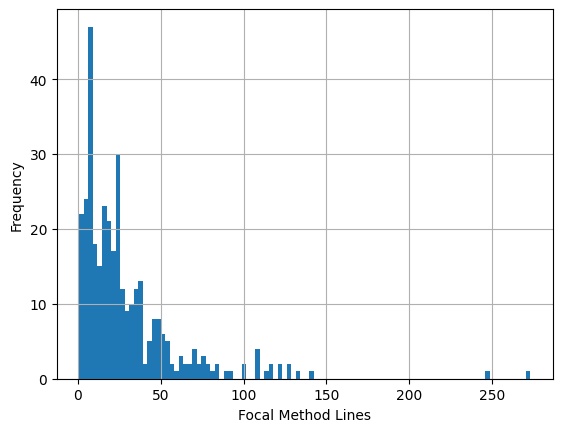

In [188]:
print(df_fm_light_final['NumberOfLines'].describe())
df_fm_light_final['NumberOfLines'].hist(bins=100)
plt.xlabel("Focal Method Lines")
plt.ylabel("Frequency")
plt.show() 

count    350.000000
mean       2.528571
std        1.808302
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       12.000000
Name: NumberOfParameters, dtype: float64


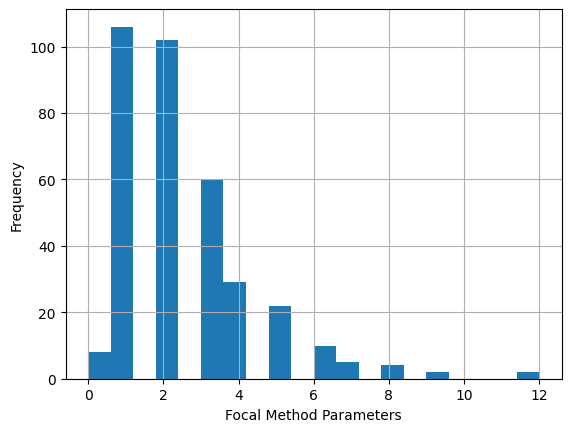

In [190]:
print(df_fm_light_final['NumberOfParameters'].describe())
df_fm_light_final['NumberOfParameters'].hist(bins=20)
plt.xlabel("Focal Method Parameters")
plt.ylabel("Frequency")
plt.show() 

count    350.000000
mean       4.200000
std        3.926984
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       26.000000
Name: NumberOfCalls, dtype: float64


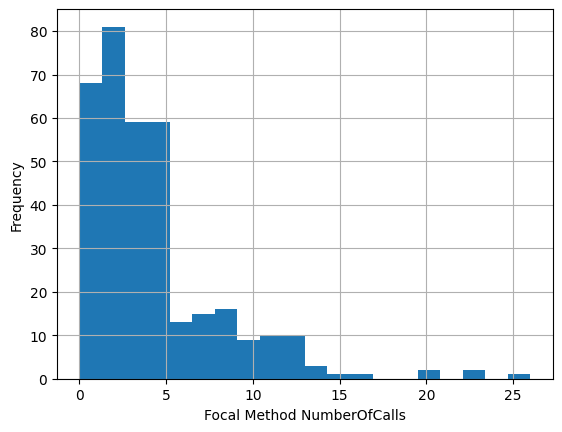

In [191]:
print(df_fm_light_final['NumberOfCalls'].describe())
df_fm_light_final['NumberOfCalls'].hist(bins=20)
plt.xlabel("Focal Method NumberOfCalls")
plt.ylabel("Frequency")
plt.show() 

count    350.000000
mean       2.440000
std        3.731781
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       27.000000
Name: NumberOfBranches, dtype: float64


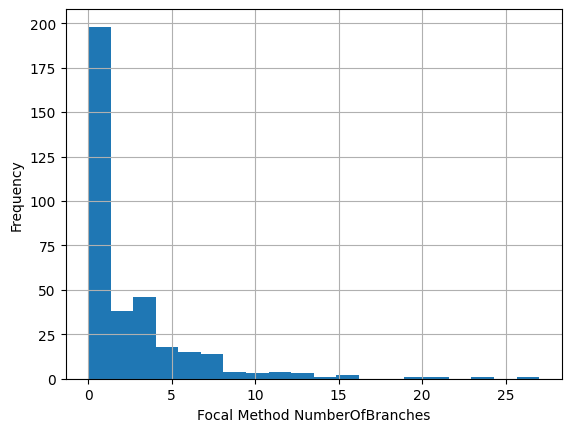

In [192]:
print(df_fm_light_final['NumberOfBranches'].describe())
df_fm_light_final['NumberOfBranches'].hist(bins=20)
plt.xlabel("Focal Method NumberOfBranches")
plt.ylabel("Frequency")
plt.show() 

In [193]:
df_fm_light_final.columns


Index(['proj_name', 'Repository', 'CommitId', 'FocalMethodFile', 'FocalMethod',
       'fm_line_num', 'NumberOfParameters', 'types', 'NumberOfBranches',
       'branch_type', 'NumberOfCalls', 'NumberOfTests', 'StartLine', 'EndLine',
       'NumberOfLines'],
      dtype='object')

count    350.000000
mean      38.777143
std       38.525719
min        1.000000
25%       14.000000
50%       28.000000
75%       48.000000
max      315.000000
dtype: float64


[]

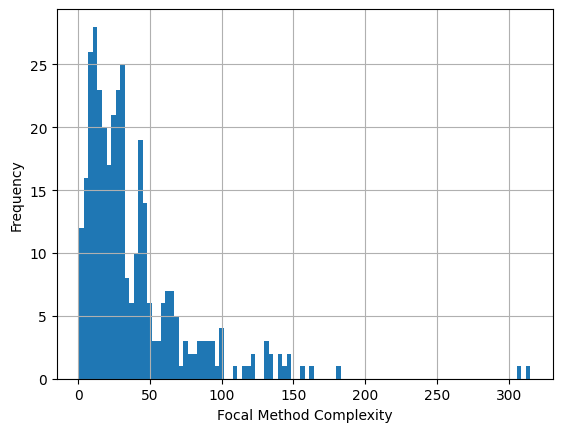

In [200]:
complexity=df_fm_light_final['NumberOfLines']+df_fm_light_final['NumberOfBranches']+df_fm_light_final['NumberOfParameters']+df_fm_light_final['NumberOfCalls']
print(complexity.describe())
complexity.hist(bins=100)
plt.xlabel("Focal Method Complexity")
plt.ylabel("Frequency")
plt.plot(color="green") 